In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)
sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name, encoding='latin1')

df.head()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1) (3).csv


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1.0,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2.0,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3.0,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4.0,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5.0,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9805 entries, 0 to 9804
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   float64
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9804 non-null   object 
 17  Sales          9804 non-null   float64
dtypes: float

In [ ]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9804.000000
mean,4900.500000,55273.322403,230.705325
std,2829.160653,32041.223413,626.534737
min,1.000000,1040.000000,0.000000
25%,2450.750000,23223.000000,17.246000
50%,4900.500000,58103.000000,54.485000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.isnull().sum()

,0
Row_ID,5
Order_ID,5
Order_Date,5
Ship_Date,5
Ship_Mode,5
Customer_ID,5
Customer_Name,5
Segment,5
Country,5
City,5


In [ ]:
df = df.drop_duplicates()

df.shape

(9805, 18)

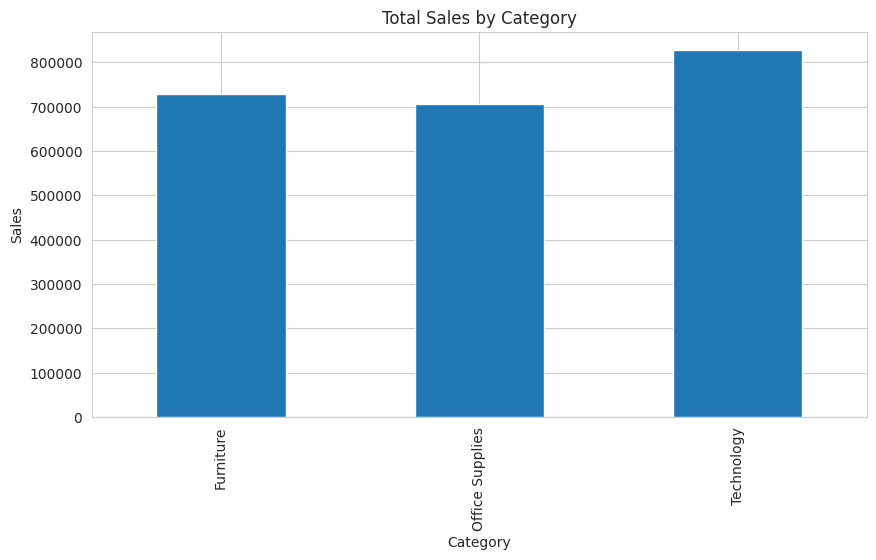

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

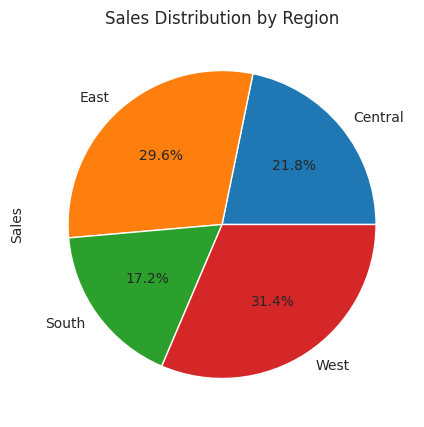

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales Distribution by Region")
plt.show()

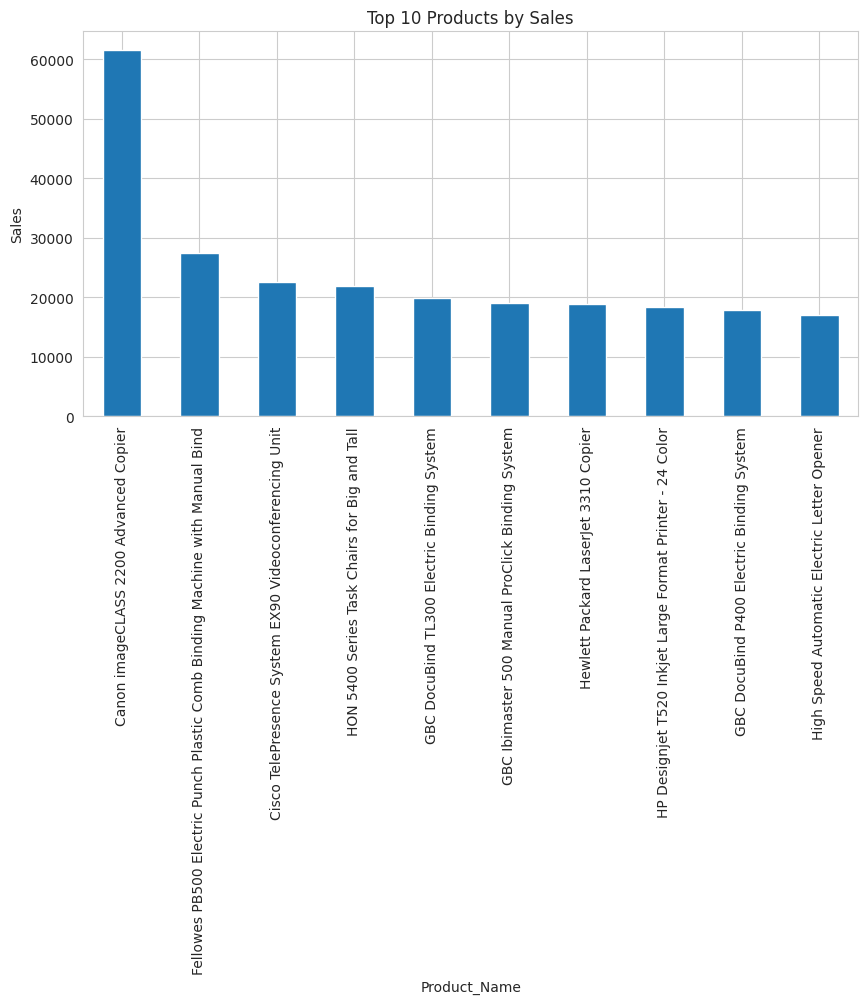

In [ ]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

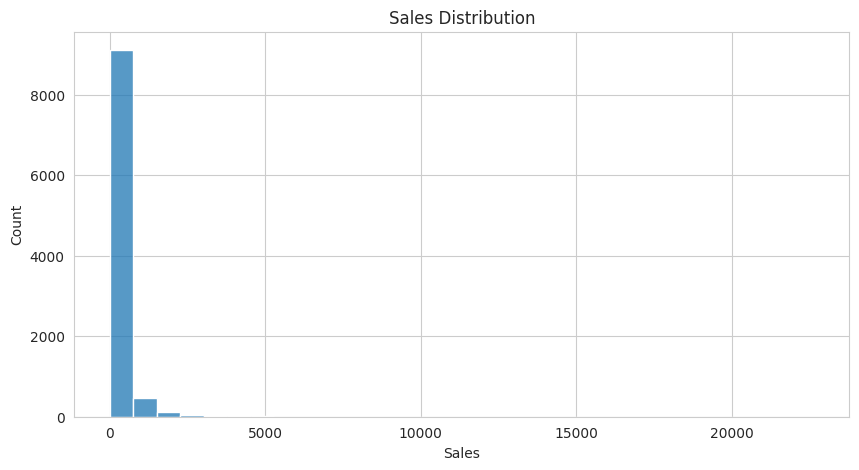

In [ ]:
sns.histplot(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.show()

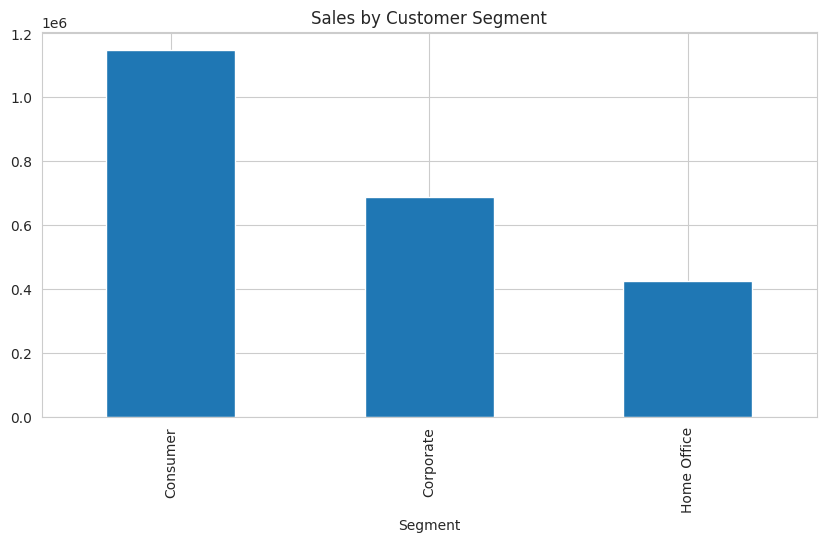

In [ ]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.show()

In [ ]:
print("Total Sales:", df["Sales"].sum())
print("Average Sales:", df["Sales"].mean())
print("Total Orders:", df["Order_ID"].nunique())
print("Total Customers:", df["Customer_ID"].nunique())

Total Sales: 2261835.0017595002
Average Sales: 230.70532453687272
Total Orders: 4922
Total Customers: 793
